# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Generative AI 코드 과제 🐻‍❄️


이번 과제에서는 VAE 모델과 DCGAN 모델을 직접 구현 및 학습하여 이미지를 생성해보고, 그 결과를 비교해보겠습니다.

- **VAE(Variational AutoEncoder)**: 입력 데이터를 저차원의 잠재 공간(latent space)으로 압축한 뒤, 이 공간의 확률 분포를 기반으로 다시 원본 데이터를 복원 및 생성하도록 하는 모델

- **GAN(Generative Adversarial Network)**: 생성자(Generator)와 판별자(Discriminator)라는 두 개의 네트워크가 서로 경쟁하며 학습하는 모델
  * Generator: Random noise를 입력받아 진짜(Real) 같은 가짜(Fake) 데이터를 생성 (=위조지폐범)
  * Discriminator: 입력받은 데이터가 Real인지 Fake인지 구분 (=경찰)

- **DCGAN (Deep Convolutional GAN)**: 기존 GAN은 단순한 MLP(Multi-Layer Perceptron) 구조인 반면, DCGAN은 이를 Convolutional 구조로 확장하여 이미지의 생성 성능을 향상시킨 모델

### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 30

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


## **VAE(Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원

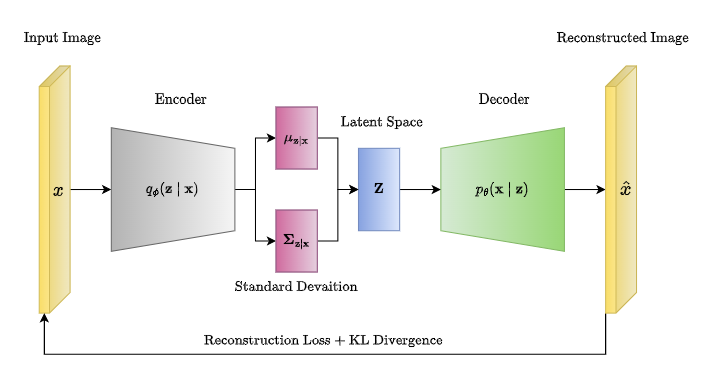

참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [5]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20, data_type="binary"):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

        self.data_type = data_type

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mean = self.fc21(h1) # 🤔 잠재분포의 평균 계산
        log_var = self.fc22(h1) # 🤔 잠재분포의 로그분산 계산
        return mean, log_var

    @staticmethod
    def reparameterize(mean, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        z = mean + std * eps
        return z

    def decode(self, z):

        h3 = F.relu(self.fc3(z))

        logits = self.fc4(h3)
        probs = torch.sigmoid(logits)

        return probs

    def forward(self, x):

        x = x.view(-1, 784)

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

### **VAE loss (ELBO)**
* Reconsturction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규븐포와 얼마나 다른지 측정

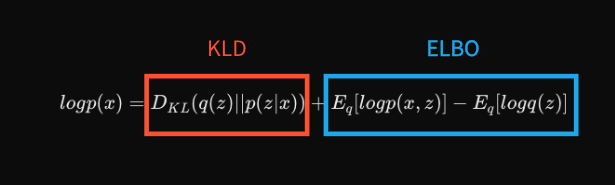


In [6]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x,x, reduction='sum') / B # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD # 🤔 빈칸을 채워주세요

    return total_loss

## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* VAE의 KLD(KL Divergence) 항은 잠재 공간을 단순한 데이터 암기 장소가 아닌, 새로운 생성이 가능한 연속적인 지도로 만들기 위해 존재한다.단순히 복원 오차($BCE$)만 고려하면 인코더는 각 데이터를 잠재 공간의 아주 좁고 파편화된 지점에만 저장하려 한다. 하지만 KLD 항은 이 공간을 표준 정규 분포($N(0, 1)$) 형태로 둥글게 모으고 데이터 간의 경계를 부드럽게 겹치게 만드는 규제 역할을 수행한다. 덕분에 잠재 공간에 빈틈이 사라지며, 우리가 그 안의 어떤 지점을 무작위로 선택해 디코딩하더라도 모델이 학습한 데이터의 특징을 가진 그럴싸한 이미지를 자연스럽게 생성할 수 있게 된다.

In [7]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):


    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x,_ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x,recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)


    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():

        for x,_ in val_loader:

            x = x.to(device)

            recon, mu, logvar = vae(x)

            loss = elbo_loss(x, recon, mu, logvar)

            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"[VAE] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

[VAE] Epoch 1/30 | Train Loss: 1.3187 | Val Loss: 1.0394
[VAE] Epoch 2/30 | Train Loss: 0.9687 | Val Loss: 0.9390
[VAE] Epoch 3/30 | Train Loss: 0.9066 | Val Loss: 0.9009
[VAE] Epoch 4/30 | Train Loss: 0.8800 | Val Loss: 0.8828
[VAE] Epoch 5/30 | Train Loss: 0.8646 | Val Loss: 0.8718
[VAE] Epoch 6/30 | Train Loss: 0.8543 | Val Loss: 0.8627
[VAE] Epoch 7/30 | Train Loss: 0.8469 | Val Loss: 0.8561
[VAE] Epoch 8/30 | Train Loss: 0.8411 | Val Loss: 0.8507
[VAE] Epoch 9/30 | Train Loss: 0.8370 | Val Loss: 0.8504
[VAE] Epoch 10/30 | Train Loss: 0.8331 | Val Loss: 0.8432
[VAE] Epoch 11/30 | Train Loss: 0.8302 | Val Loss: 0.8412
[VAE] Epoch 12/30 | Train Loss: 0.8277 | Val Loss: 0.8400
[VAE] Epoch 13/30 | Train Loss: 0.8253 | Val Loss: 0.8386
[VAE] Epoch 14/30 | Train Loss: 0.8236 | Val Loss: 0.8375
[VAE] Epoch 15/30 | Train Loss: 0.8217 | Val Loss: 0.8343
[VAE] Epoch 16/30 | Train Loss: 0.8198 | Val Loss: 0.8325
[VAE] Epoch 17/30 | Train Loss: 0.8183 | Val Loss: 0.8342
[VAE] Epoch 18/30 | Tra

**VAE sampling 시각화**

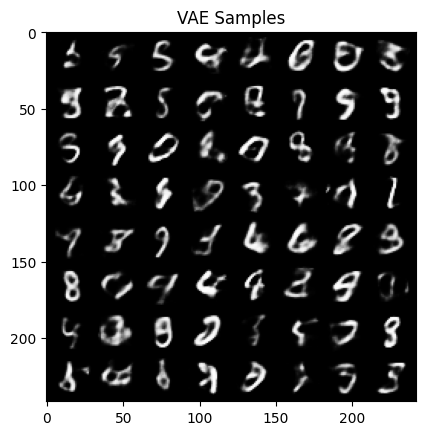

In [8]:
with torch.no_grad():

    z = torch.randn(64,20).to(device)

    samples = vae.decode(z).view(-1,1,28,28)

    grid = make_grid(samples,8)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("VAE Samples")
plt.show()

## **DCGAN(Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - LeakyReLU: 음수 영역에 작은 양수 기울기를 부여하여 Gradient Vanishing 문제를 해결
  - Activation: 마지막 layer에 sigmoid를 사용하여 real(1)/fake(0) 사이의 확률 값을 출력


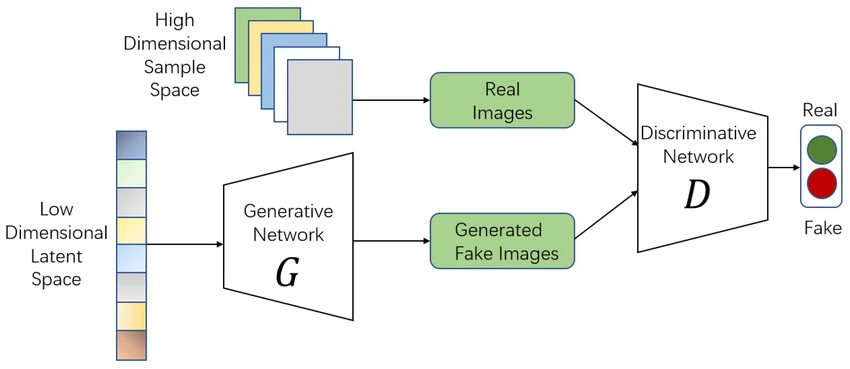


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [10]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [11]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size,256,7,1,0,bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128,64,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64,1,3,1,1,bias=False)

    def forward(self,x):

        x = F.relu(self.bn1(self.tconv1(x)))
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))

        x = torch.tanh(self.tconv4(x))

        return x

In [12]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=64,kernel_size=4,stride=2,padding=1,bias=False)

        self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256,1,3,1,0,bias=False)

    def forward(self,x):

        x = F.leaky_relu(self.conv1(x),0.2,True)

        x = F.leaky_relu(self.bn2(self.conv2(x)),0.2,True)

        x = F.leaky_relu(self.bn3(self.conv3(x)),0.2,True)

        x = torch.sigmoid(self.conv4(x))

        return x.view(-1)

In [13]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(),0.0002,betas=(0.5,0.999))
optD = optim.Adam(D.parameters(),0.0002,betas=(0.5,0.999))

In [15]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x,_ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)


        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0),latent_size,1,1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()


        # ========== Train Generator ==========

        lossG = criterion(D(fake_img), real) # 🤔 빈칸을 채워주세요

        optG.zero_grad()
        lossG.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += lossG.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"[DCGAN] Epoch {epoch+1}/{epochs} | Train D Loss {train_lossD:.4f} | Train G Loss {train_lossG:.4f}")

[DCGAN] Epoch 1/30 | Train D Loss 0.7545 | Train G Loss 1.8487
[DCGAN] Epoch 2/30 | Train D Loss 0.9142 | Train G Loss 1.4585
[DCGAN] Epoch 3/30 | Train D Loss 0.9639 | Train G Loss 1.3672
[DCGAN] Epoch 4/30 | Train D Loss 0.9988 | Train G Loss 1.3519
[DCGAN] Epoch 5/30 | Train D Loss 1.0025 | Train G Loss 1.3550
[DCGAN] Epoch 6/30 | Train D Loss 0.9976 | Train G Loss 1.3654
[DCGAN] Epoch 7/30 | Train D Loss 1.0047 | Train G Loss 1.3656
[DCGAN] Epoch 8/30 | Train D Loss 0.9823 | Train G Loss 1.4040
[DCGAN] Epoch 9/30 | Train D Loss 0.9793 | Train G Loss 1.4413
[DCGAN] Epoch 10/30 | Train D Loss 0.9840 | Train G Loss 1.4192
[DCGAN] Epoch 11/30 | Train D Loss 1.0008 | Train G Loss 1.4069
[DCGAN] Epoch 12/30 | Train D Loss 0.9616 | Train G Loss 1.4633
[DCGAN] Epoch 13/30 | Train D Loss 0.9412 | Train G Loss 1.5011
[DCGAN] Epoch 14/30 | Train D Loss 0.9379 | Train G Loss 1.5167
[DCGAN] Epoch 15/30 | Train D Loss 0.9299 | Train G Loss 1.5442
[DCGAN] Epoch 16/30 | Train D Loss 0.9305 | Train

**DCGAN Sampling 시각화**

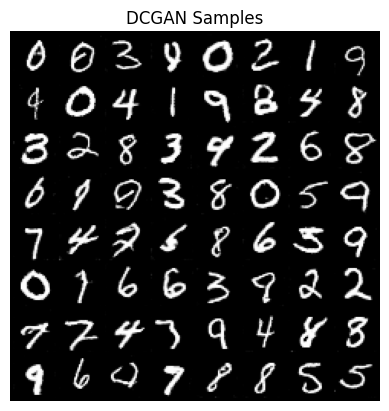

In [16]:
G.eval()

with torch.no_grad():

    z = torch.randn(64,latent_size,1,1).to(device)

    samples = G(z)

grid = make_grid(samples,8,normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()

## **🙋 [GAN] Question 2-1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 데이터의 확률 분포를 직접 모델링하며 픽셀 단위의 Reconstruction Loss을 최소화하는 방식을 취한다. 이 과정에서 모델은 발생 가능한 여러 이미지의 통계적 '평균'을 출력하려는 경향을 보이기에 세부 경계가 뭉개진 흐릿한 이미지를 생성하게 된다. 반면 DCGAN은 판별자와 생성자가 경쟁하는 적대적 학습 방식을 사용한다. 생성자는 판별자를 완벽히 속이기 위해 실제 데이터의 날카로운 특징과 디테일을 그대로 재현하도록 강제되므로, 픽셀 간의 단순 평균값이 아닌 시각적으로 훨씬 선명하고 사실적인 결과물을 도출하게 된다.



## **🙋 [GAN] Question 2-2**
GAN 학습 과정에서 Generator의 Loss가 증가하는 것이 반드시 모델 성능 악화를 의미하지 않는 이유는 무엇인지 설명해주세요.

* GAN 학습은 생성자($G$)와 판별자($D$)가 서로 대립하며 발전하는 적대적 게임의 형태를 띤다. 따라서 특정 시점에 생성자의 손실(Loss)이 증가하는 현상이 반드시 모델의 성능 악화를 뜻하지는 않는다.첫째, 손실 함수의 상대성 때문이다. 생성자의 손실값은 판별자가 내놓는 결과에 직접적으로 의존한다. 만약 판별자가 생성자보다 더 빠르게 학습하여 가짜 데이터를 정교하게 가려내기 시작하면, 생성자가 이전보다 더 나은 이미지를 생성하고 있더라도 수치상의 손실값은 상승하게 된다. 이는 생성자가 퇴보한 것이 아니라, 넘어야 할 판별자의 벽이 높아진 것으로 해석해야 한다.
* 둘째, Nash Equilibrium을 향한 과정이기 때문이다. GAN 학습의 목표는 일반적인 지도학습처럼 손실을 0으로 만드는 것이 아니라, 판별자가 진짜와 가짜를 전혀 구분하지 못하는 확률인 $0.5$에 수렴하도록 만드는 것이다. 이 과정에서 두 모델은 서로의 성능을 견제하며 손실값이 오르내리는 역동적인 진동을 겪게 된다. 따라서 실질적인 성능 평가는 단순한 Loss 수치보다는 생성된 이미지의 시각적 품질이나 별도의 평가지표를 통해 판단하는 것이 타당하다.

수고하셨습니다 ☺️